In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sns.set_theme(style="ticks", font_scale=1.15)

penguins  = sns.load_dataset("penguins").dropna()
healthexp = sns.load_dataset("healthexp")


## 1 Â· The problem: one extreme value that crushes the rest

US health expenditure (~\$12 000/yr) is roughly twice the next-highest country. On a single scale, every other country collapses into a narrow band at the bottom. A y-axis break solves this cleanly â€” no data is hidden, and both ranges are readable.

---

## Iris: morphologically distinct groups

*Iris setosa* has petals 1–2 cm long — roughly half the length of *I. versicolor* and *I. virginica* (3–7 cm). This 1 cm gap is biologically real: setosa belongs to a different subgenus. On a single shared x-axis the setosa cluster is compressed into a sliver; a broken x-axis gives each cluster its own resolution while making the discontinuity explicit.

In [ ]:
iris = sns.load_dataset("iris")

g = sns.BrokenAxes(
    xlims=[(0.8, 2.3), (2.7, 7.2)],
    width_ratios=[1, 3],
    wspace=0.08,
)
g.plot(
    sns.scatterplot,
    data=iris,
    x="petal_length",
    y="petal_width",
    hue="species",
    s=60, alpha=0.85,
    legend_ax=g.ax_right,
)
g.set_axis_labels("Petal length (cm)", "Petal width (cm)")
g.fig.set_size_inches(9, 4)

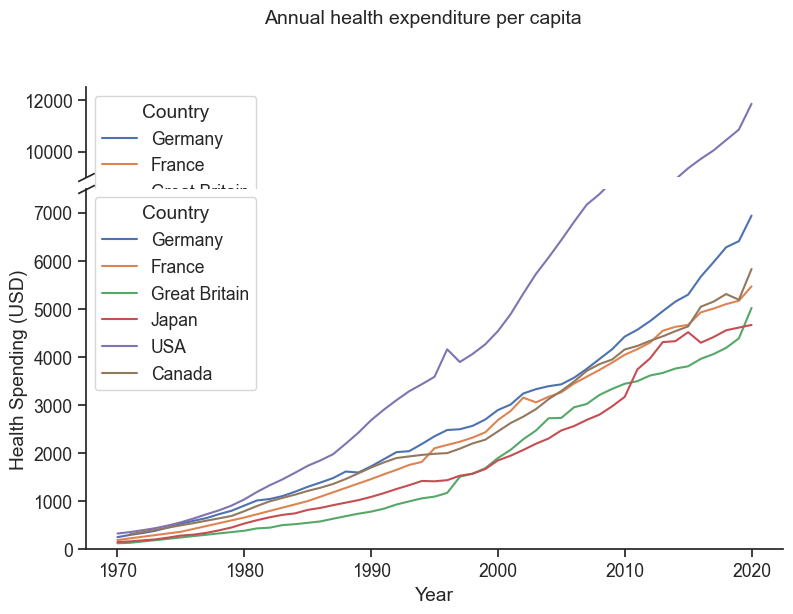

In [3]:
g = sns.BrokenAxes(
    ylims=[(0, 7500), (9000, 12500)],
    height_ratios=[4, 1],
)
g.plot(
    sns.lineplot,
    data=healthexp, x="Year", y="Spending_USD", hue="Country",
)
g.set_axis_labels("Year", "Health Spending (USD)")
g.fig.suptitle("Annual health expenditure per capita", y=1.01, fontsize=14)
g.fig.set_size_inches(9, 6)

## 2 Â· Penguins: body size outliers across species

Gentoo penguins are substantially heavier than Adelie and Chinstrap â€” all Adelie and Chinstrap individuals fall below 4 800 g, while the largest Gentoo reach 6 300 g. A y-break separates the two clusters without distorting the scale within either group.

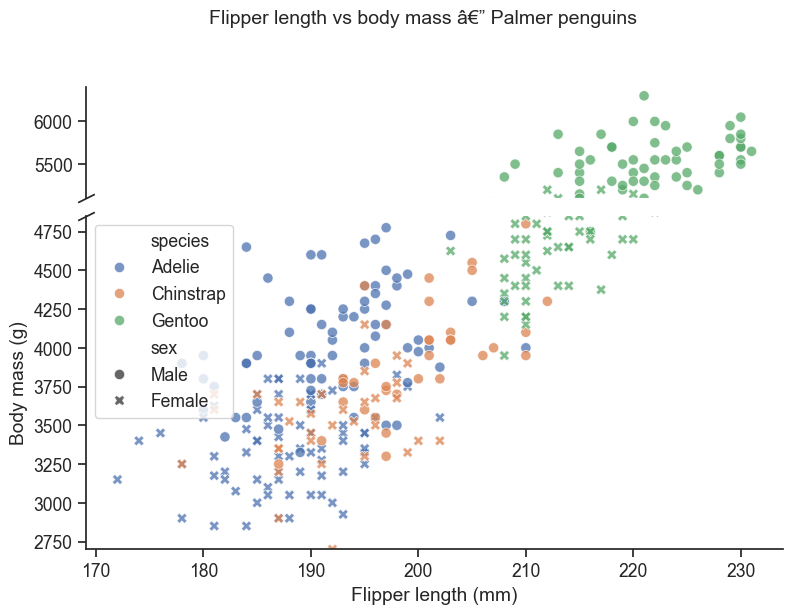

In [4]:
palette = {"Adelie": "#4C72B0", "Chinstrap": "#DD8452", "Gentoo": "#55A868"}

g = sns.BrokenAxes(
    ylims=[(2700, 4850), (5100, 6400)],
    height_ratios=[3, 1],
    hspace=0.08,
)
for ax in g.axes:
    sns.scatterplot(
        data=penguins, x="flipper_length_mm", y="body_mass_g",
        hue="species", style="sex", palette=palette,
        alpha=0.75, s=55, ax=ax,
        legend=(ax is g.ax_bottom),
    )
g.set_axis_labels("Flipper length (mm)", "Body mass (g)")
g.ax_bottom.legend(title="", loc="upper left", frameon=True)
g.fig.suptitle("Flipper length vs body mass â€” Palmer penguins", y=1.01, fontsize=14)
g.fig.set_size_inches(9, 6)

## 3 Â· Distribution by species â€” same break, different chart type

The `.plot()` method is chart-agnostic: the same `BrokenAxes` object works with any seaborn function. Here a boxplot makes the intra-species spread visible alongside the inter-species gap.

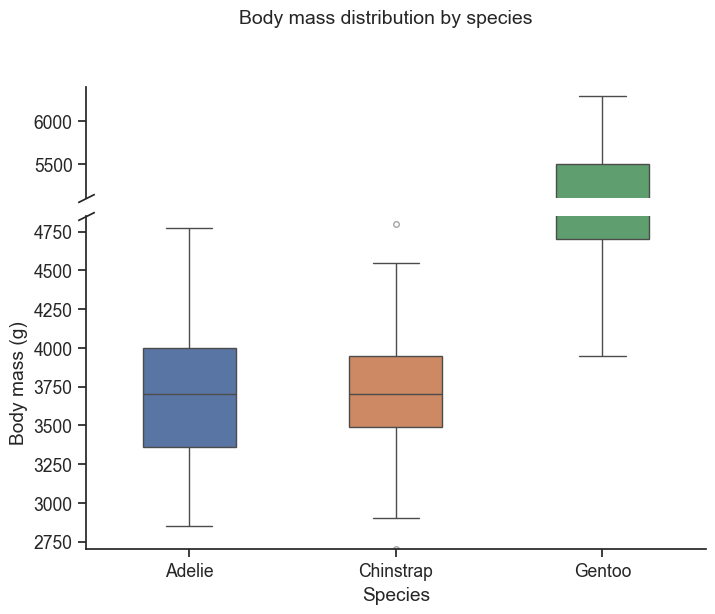

In [5]:
g = sns.BrokenAxes(
    ylims=[(2700, 4850), (5100, 6400)],
    height_ratios=[3, 1],
    hspace=0.08,
)
g.plot(
    sns.boxplot,
    data=penguins, x="species", y="body_mass_g",
    hue="species", palette=palette, width=0.45, legend=False,
    flierprops=dict(marker="o", markersize=4, alpha=0.5),
    clip_data=False,
)
g.set_axis_labels("Species", "Body mass (g)")
g.fig.suptitle("Body mass distribution by species", y=1.01, fontsize=14)
g.fig.set_size_inches(8, 6)

## 4 Â· X-axis break: isolating the Gentoo flipper cluster

Breaks work on either axis. Gentoo flippers are distinctly longer than those of Adelie and Chinstrap â€” an x-break places the two size classes side-by-side without implying continuity between them.

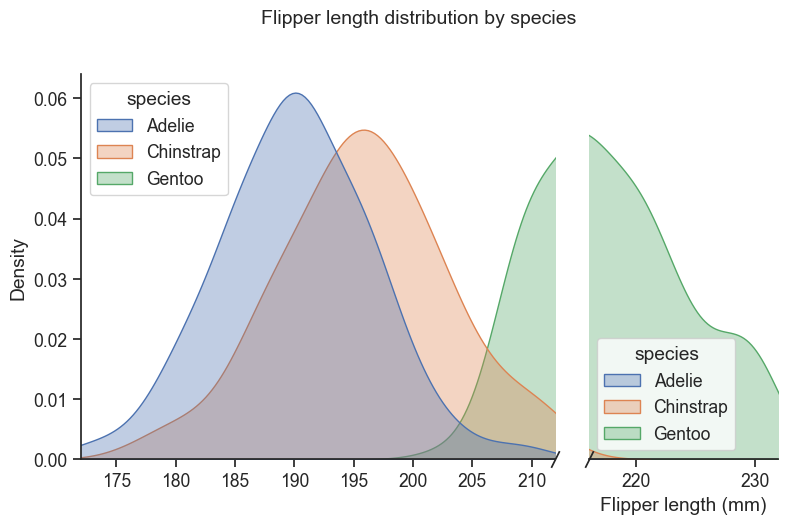

In [6]:
g = sns.BrokenAxes(
    xlims=[(172, 212), (216, 232)],
    width_ratios=[5, 2],
    wspace=0.1,
)
g.plot(
    sns.kdeplot,
    data=penguins, x="flipper_length_mm",
    hue="species", palette=palette,
    fill=True, alpha=0.35, common_norm=False,
    clip_data=False,
)
g.set_axis_labels("Flipper length (mm)", "Density")
g.fig.suptitle("Flipper length distribution by species", y=1.01, fontsize=14)
g.fig.set_size_inches(9, 5)

## 5 Â· Three segments: when the data has multiple distinct clusters

When a dataset has more than one outlier cluster, additional segments can be added by extending the `ylims` list. Each consecutive pair of entries creates a break, and `height_ratios` allocates visual space proportionally.

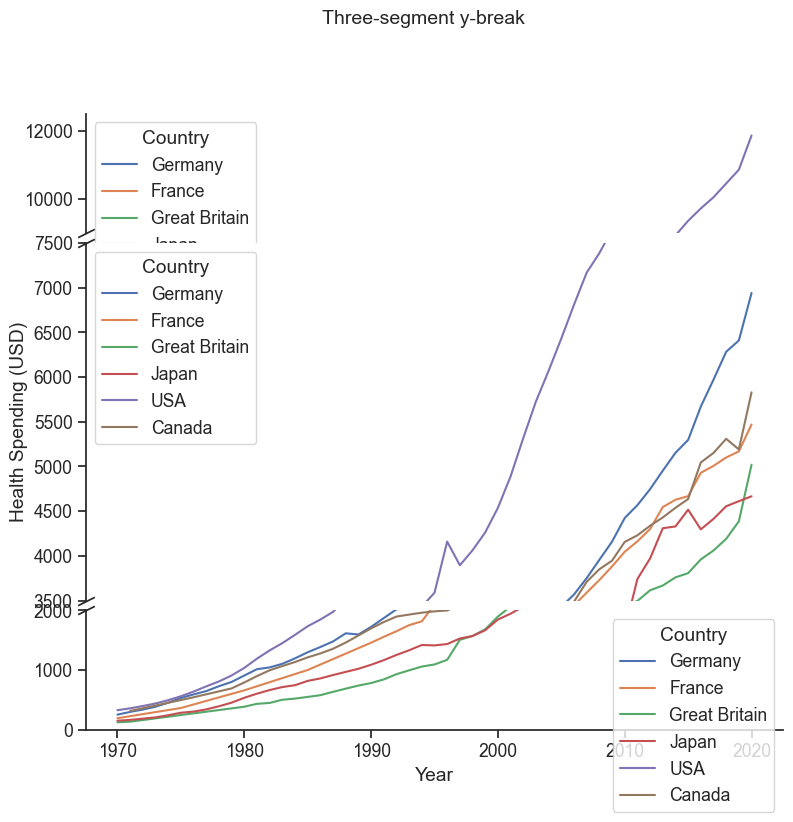

In [7]:
g = sns.BrokenAxes(
    ylims=[(0, 2000), (3500, 7500), (9000, 12500)],
    height_ratios=[1, 3, 1],
)
g.plot(
    sns.lineplot,
    data=healthexp, x="Year", y="Spending_USD", hue="Country",
)
g.set_axis_labels("Year", "Health Spending (USD)")
g.fig.suptitle("Three-segment y-break", y=1.01, fontsize=14)
g.fig.set_size_inches(9, 8)

## 6 Â· Embedding alongside regular panels

Unlike `JointGrid` or `FacetGrid`, a `BrokenAxes` instance can be embedded as a single cell inside a larger figure layout via the `subplot_spec` parameter. This is the main architectural difference: the broken-axis panel shares a figure with ordinary axes rather than owning a standalone one.

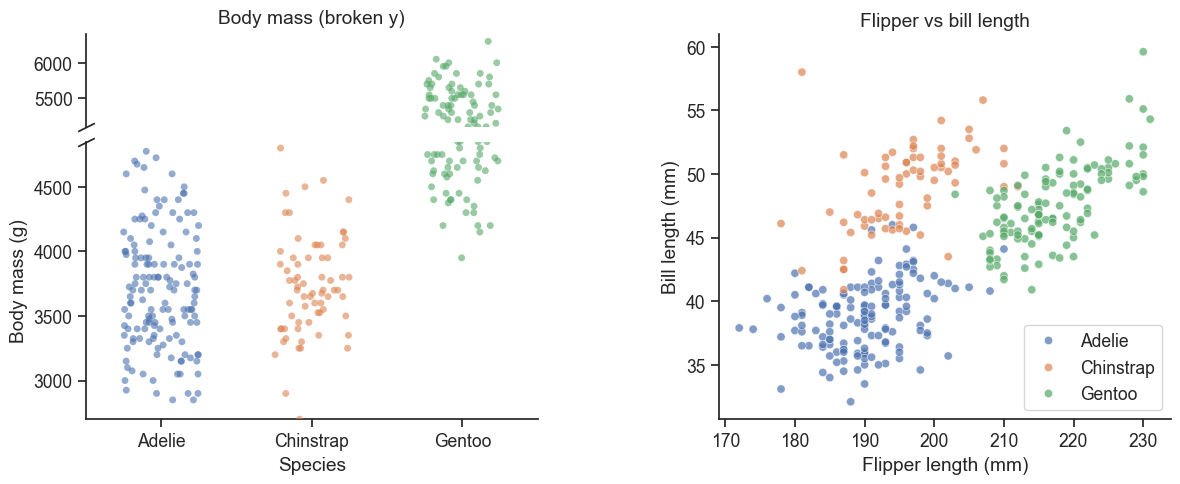

In [8]:
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)

# Left: broken-axis panel
g = sns.BrokenAxes(
    ylims=[(2700, 4850), (5100, 6400)],
    height_ratios=[3, 1],
    hspace=0.08,
    subplot_spec=gs[0, 0],
)
g.plot(
    sns.stripplot,
    data=penguins, x="species", y="body_mass_g",
    hue="species", palette=palette,
    dodge=False, alpha=0.6, jitter=0.25, legend=False,
    clip_data=False,
)
g.set_axis_labels("Species", "Body mass (g)")
g.ax_top.set_title("Body mass (broken y)", pad=8)

# Right: ordinary panel
ax = fig.add_subplot(gs[0, 1])
sns.scatterplot(
    data=penguins, x="flipper_length_mm", y="bill_length_mm",
    hue="species", palette=palette, alpha=0.7, ax=ax,
)
ax.set(xlabel="Flipper length (mm)", ylabel="Bill length (mm)",
       title="Flipper vs bill length")
sns.despine(ax=ax)
ax.legend(title="")

---

## 7 Â· Military spending â€” when one number dwarfs the rest

Global defence expenditure (SIPRI, 2023) has a structural outlier: US spending (\$916B) is more than three times China's (\$296B), which is itself nearly three times Russia's (\$109B). A two-segment break collapses the empty middle of the scale and puts the full hierarchy in view simultaneously.

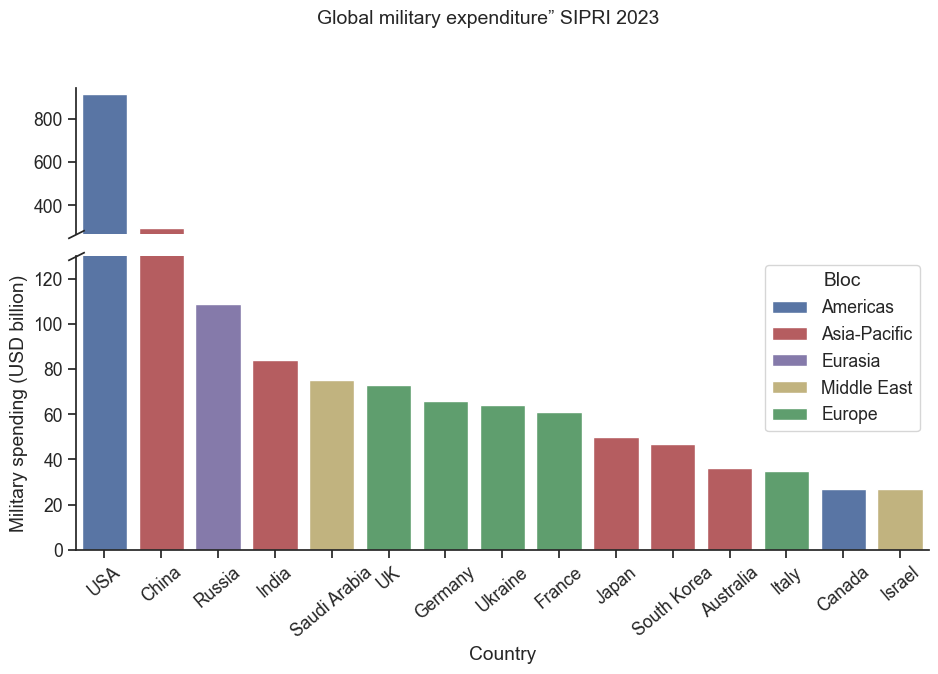

In [9]:
import pandas as pd

mil = pd.DataFrame({
    "Country": [
        "USA", "China", "Russia", "India", "Saudi Arabia",
        "Ukraine", "Germany", "UK", "France", "Japan",
        "South Korea", "Australia", "Italy", "Canada", "Israel",
    ],
    "Spending": [916, 296, 109, 84, 75, 64, 66, 73, 61, 50, 47, 36, 35, 27, 27],
    "Bloc": [
        "Americas", "Asia-Pacific", "Eurasia", "Asia-Pacific", "Middle East",
        "Europe", "Europe", "Europe", "Europe", "Asia-Pacific",
        "Asia-Pacific", "Asia-Pacific", "Europe", "Americas", "Middle East",
    ],
})
mil = mil.sort_values('Spending', ascending=False)

bloc_palette = {
    "Americas":     "#4C72B0",
    "Europe":       "#55A868",
    "Asia-Pacific": "#C44E52",
    "Eurasia":      "#8172B2",
    "Middle East":  "#CCB974",
}

g = sns.BrokenAxes(
    ylims=[(0, 130), (265, 945)],
    height_ratios=[2, 1],
    hspace=0.1,
)
g.plot(
    sns.barplot,
    data=mil, x="Country", y="Spending",
    hue="Bloc", palette=bloc_palette, dodge=False, legend=True,
    clip_data=False,
)
g.set_axis_labels("Country", "Military spending (USD billion)")
g.ax_bottom.tick_params(axis="x", rotation=40)
g.ax_bottom.legend(title="Bloc", loc="upper right", frameon=True)
g.fig.suptitle("Global military expenditure” SIPRI 2023", y=1.01, fontsize=14)
g.fig.set_size_inches(11, 6)

---

## 8 Â· COâ‚‚ emissions â€” the Gulf outlier problem

Per-capita COâ‚‚ emissions (Our World in Data, 2022) show a textbook case: Qatar (31.7 t), Kuwait (22.6 t) and the UAE (21.2 t) sit so far above every other country that a conventional x-axis flattens the rest of the distribution into illegibility. An x-break isolates the Gulf cluster on the right while preserving detail across the main distribution on the left. The negative correlation between emissions and life expectancy is now legible in both panels.

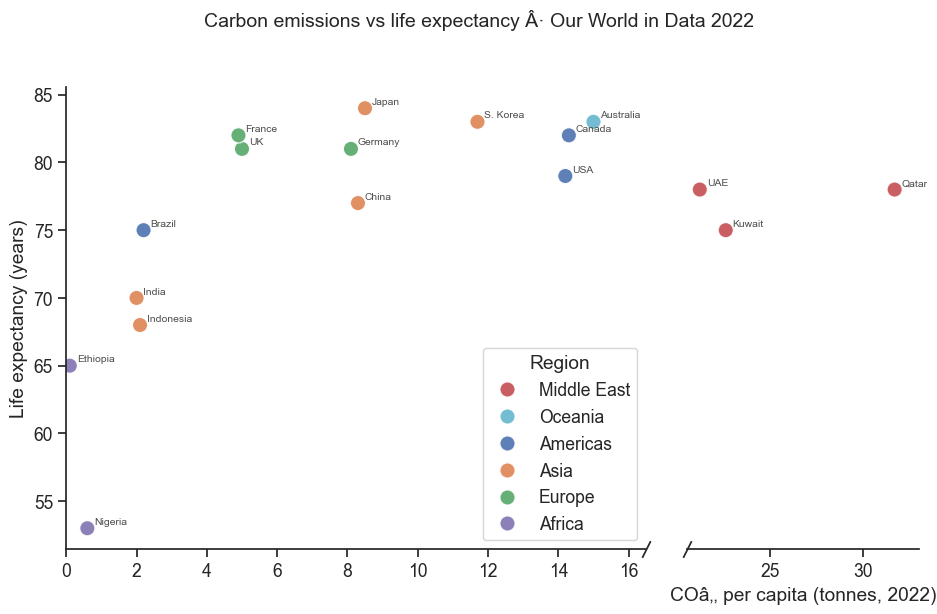

In [10]:
co2 = pd.DataFrame({
    "Country": [
        "Qatar", "Kuwait", "UAE", "Bahrain",
        "Australia", "USA", "Canada",
        "S. Korea", "Germany", "Japan",
        "UK", "France", "China",
        "Brazil", "India", "Indonesia",
        "Nigeria", "Ethiopia",
    ],
    "CO2_pc": [
        31.7, 22.6, 21.2, 18.0,
        15.0, 14.2, 14.3,
        11.7,  8.1,  8.5,
         5.0,  4.9,  8.3,
         2.2,  2.0,  2.1,
         0.6,  0.1,
    ],
    "Life_exp": [
        78, 75, 78, 77,
        83, 79, 82,
        83, 81, 84,
        81, 82, 77,
        75, 70, 68,
        53, 65,
    ],
    "Region": [
        "Middle East", "Middle East", "Middle East", "Middle East",
        "Oceania", "Americas", "Americas",
        "Asia", "Europe", "Asia",
        "Europe", "Europe", "Asia",
        "Americas", "Asia", "Asia",
        "Africa", "Africa",
    ],
})

region_palette = {
    "Middle East": "#C44E52",
    "Oceania":     "#64B5CD",
    "Americas":    "#4C72B0",
    "Europe":      "#55A868",
    "Asia":        "#DD8452",
    "Africa":      "#8172B2",
}

g = sns.BrokenAxes(
    xlims=[(0, 16.5), (20.5, 33)],
    width_ratios=[5, 2],
    wspace=0.1,
)
for ax in g.axes:
    sns.scatterplot(
        data=co2, x="CO2_pc", y="Life_exp",
        hue="Region", palette=region_palette,
        s=120, alpha=0.9, ax=ax,
        legend=(ax is g.ax_left),
    )
    for _, row in co2.iterrows():
        ax.annotate(
            row["Country"],
            (row["CO2_pc"], row["Life_exp"]),
            textcoords="offset points", xytext=(5, 3),
            fontsize=7.5, color=".3",
        )
g.set_axis_labels("COâ‚‚ per capita (tonnes, 2022)", "Life expectancy (years)")
g.ax_left.legend(title="Region", frameon=True, loc="lower right")
g.fig.suptitle("Carbon emissions vs life expectancy Â· Our World in Data 2022",
               y=1.01, fontsize=14)
g.fig.set_size_inches(11, 6)

---

## 9 Â· GDP per capita â€” three tiers, one chart

World Bank 2022 GDP per capita spans three orders of magnitude. A three-segment break separates low-income economies (\$1â€“5 k), middle-to-high income economies (\$10â€“55 k), and the ultra-high tier (Luxembourg, Switzerland, Norway) without distorting scale within any group. No data is hidden â€” the full distribution is visible across all three panels.

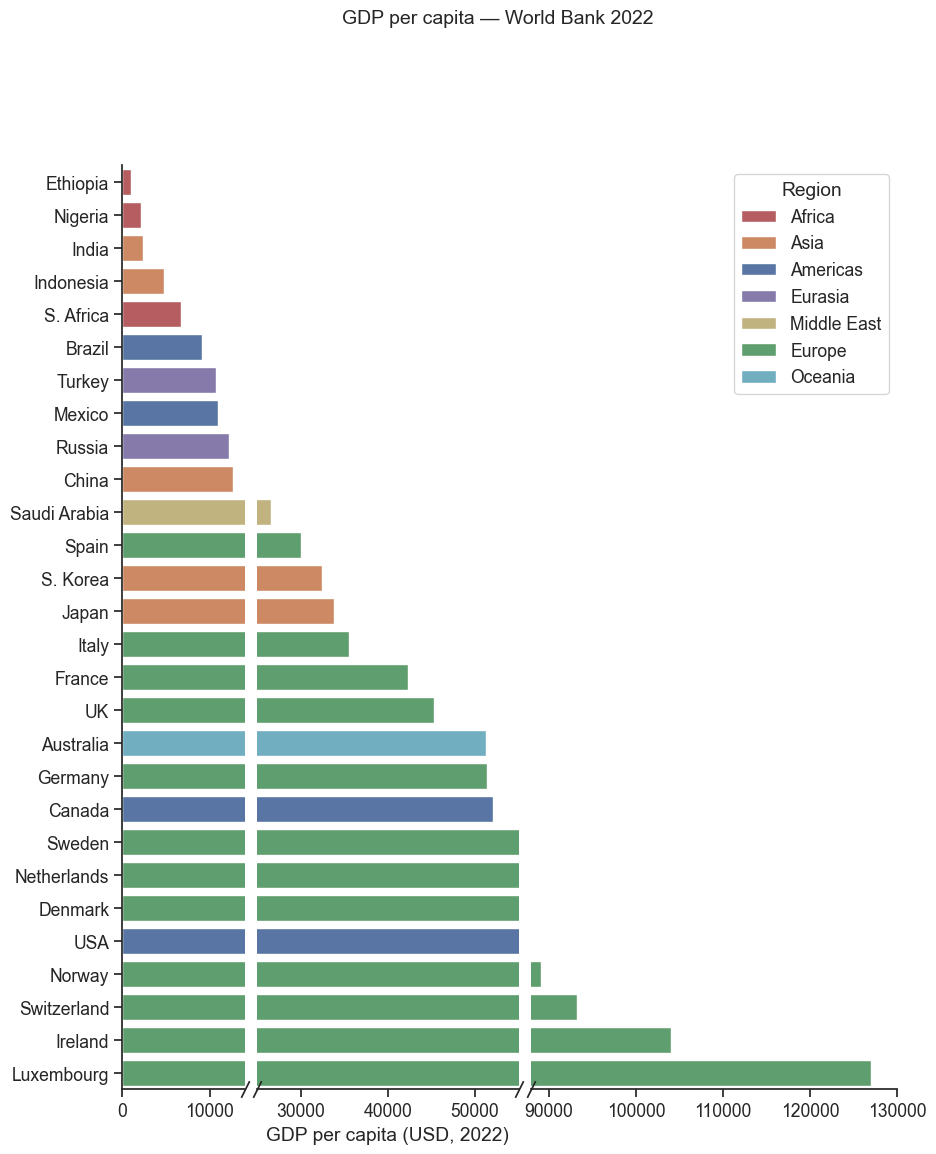

In [11]:
gdp = pd.DataFrame({
    "Country": [
        "Ethiopia", "Nigeria", "India", "Indonesia",
        "China", "Brazil", "Mexico", "S. Africa",
        "Russia", "Turkey", "Saudi Arabia",
        "S. Korea", "Japan", "Spain", "Italy",
        "France", "UK", "Canada", "Germany", "Australia",
        "USA", "Sweden", "Netherlands", "Denmark",
        "Ireland", "Norway", "Switzerland", "Luxembourg",
    ],
    "GDP_pc": [
         1020,  2085,  2389,  4788,
        12720,  9130, 10950,  6766,
        12194, 10674, 26590,
        32423, 33815, 30090, 35551,
        42330, 45295, 52051, 51380, 51218,
        76330, 55220, 57767, 67790,
       103985, 89090, 93260, 127006,
    ],
    "Region": [
        "Africa", "Africa", "Asia", "Asia",
        "Asia", "Americas", "Americas", "Africa",
        "Eurasia", "Eurasia", "Middle East",
        "Asia", "Asia", "Europe", "Europe",
        "Europe", "Europe", "Americas", "Europe", "Oceania",
        "Americas", "Europe", "Europe", "Europe",
        "Europe", "Europe", "Europe", "Europe",
    ],
})
gdp = gdp.sort_values("GDP_pc")

region_palette2 = {
    "Africa":      "#C44E52",
    "Asia":        "#DD8452",
    "Americas":    "#4C72B0",
    "Europe":      "#55A868",
    "Eurasia":     "#8172B2",
    "Middle East": "#CCB974",
    "Oceania":     "#64B5CD",
}

g = sns.BrokenAxes(
    xlims=[(0, 14000), (25000, 55000), (88000, 130000)],
    height_ratios=[2, 3, 1],
    hspace=0.1,
)
g.plot(
    sns.barplot,
    data=gdp, y="Country", x="GDP_pc",
    hue="Region", palette=region_palette2, dodge=False,
    orient="h", legend=True, clip_data=False,
)
g.set_axis_labels("GDP per capita (USD, 2022)", "")
g.fig.suptitle("GDP per capita — World Bank 2022", y=1.01, fontsize=14)
g.fig.set_size_inches(10, 12)


---

## 10 · XKCD: Fields Arranged by Purity — now with philosophers

The original XKCD notes that mathematicians are so pure they can barely see the other fields. But where do philosophers sit on this axis?

Positions: Sociologists=1, Psychologists=3, Biologists=6, Chemists=10, Physicists=15, Mathematicians=30. Philosopher: **100**.

The philosopher is calmly sitting at 100 — unreachable without a break. And they have exactly one thing to say about it.

C:\Users\Aditya\AppData\Local\Temp\ipykernel_6872\3233793112.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.


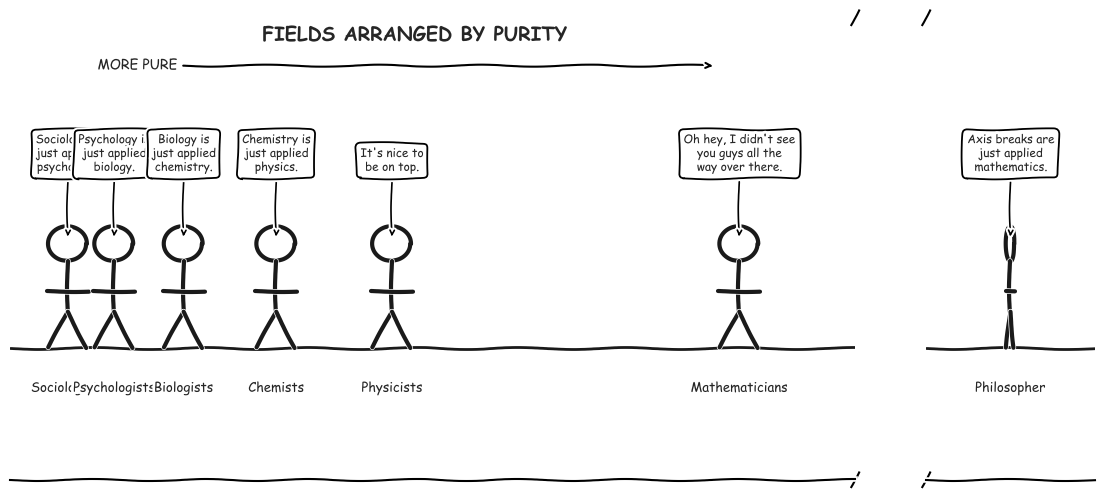

In [12]:
# XKCD: Fields arranged by purity
import numpy as np

fields    = ['Sociologists', 'Psychologists', 'Biologists',
             'Chemists', 'Physicists', 'Mathematicians', 'Philosopher']
positions = [1, 3, 6, 10, 15, 30, 100]

speeches = {
    'Sociologists':   'Sociology is\njust applied\npsychology.',
    'Psychologists':  'Psychology is\njust applied\nbiology.',
    'Biologists':     'Biology is\njust applied\nchemistry.',
    'Chemists':       'Chemistry is\njust applied\nphysics.',
    'Physicists':     "It's nice to\nbe on top.",
    'Mathematicians': "Oh hey, I didn't see\nyou guys all the\nway over there.",
    'Philosopher':    "Axis breaks are\njust applied\nmathematics.",
}


def draw_stick(ax, x, yscale=1.0, color='k'):
    """Proportional stick figure: arms/legs scale with the axis x-range
    so the figure looks correct regardless of which panel it lives in."""
    xlo, xhi = ax.get_xlim()
    xs = (xhi - xlo) * 0.025
    ys = yscale
    kw = dict(color=color, lw=3, solid_capstyle='round')
    t  = np.linspace(0, 2 * np.pi, 60)
    ax.plot(x + xs * 0.9 * np.cos(t),
            1.73*ys + 0.28*ys * np.sin(t), **kw)          # head
    ax.plot([x, x],         [1.45*ys, 0.6*ys], **kw)      # body
    ax.plot([x-xs, x+xs],   [0.95*ys, 0.95*ys], **kw)     # arms
    ax.plot([x, x-xs*0.9],  [0.6*ys, 0], **kw)            # left leg
    ax.plot([x, x+xs*0.9],  [0.6*ys, 0], **kw)            # right leg


with plt.xkcd(scale=1, length=120, randomness=2):

    g = sns.BrokenAxes(
        xlims=[(-1.5, 35), (93, 107)],
        width_ratios=[5, 1],
        wspace=0.14,
        despine=False,
    )
    g.fig.set_size_inches(14, 6)

    for ax in g.axes:
        xlo, xhi = ax.get_xlim()
        ax.set_ylim(-2.2, 5.5)
        ax.set_yticks([])
        ax.set_xticks([])
        for spine in ['left', 'right', 'top']:
            ax.spines[spine].set_visible(False)
        ax.axhline(0, color='k', lw=2, zorder=1)

        for name, pos in zip(fields, positions):
            if not (xlo - 1 <= pos <= xhi + 1):
                continue
            draw_stick(ax, pos)
            ax.text(pos, -0.55, name, ha='center', va='top', fontsize=9.5)
            ax.annotate(
                speeches[name],
                xy=(pos, 1.8), xytext=(pos, 2.9),
                ha='center', va='bottom', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='black', lw=1.3),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            )

    # title and MORE PURE arrow on the left panel
    ax0 = g.ax_left
    ax0.text(16, 5.2, 'FIELDS ARRANGED BY PURITY',
             ha='center', va='center', fontsize=14, fontweight='bold')
    ax0.annotate(
        'MORE PURE',
        xy=(29, 4.7), xytext=(4, 4.7),
        ha='center', va='center', fontsize=10,
        arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    )
    plt.tight_layout()
